# 08 -- Confidence Calibration
## LLM Lie Detector | Phase 6

This notebook extends the base detector with proper confidence calibration.
The current system returns binary confidence (high/low). This notebook
replaces that with calibrated probability scores and evaluates them using
ROC curves, calibration plots, and uncertainty thresholds.

### Goals
- Extract token-level probability scores from the model's output logits
- Compute calibrated confidence scores for each prediction
- Plot ROC curve and compute AUC score
- Plot reliability diagram (calibration curve)
- Define uncertainty thresholds for production use

### Why This Matters
Binary confidence is a known limitation of the current system. A production
hallucination detector needs to express uncertainty -- not just "HALLUCINATED"
but "HALLUCINATED with 94% confidence" vs "HALLUCINATED with 61% confidence".
The latter should trigger human review rather than automatic rejection.

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
import os
os.environ["PYTHONUTF8"] = "1"

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, brier_score_loss
from sklearn.calibration import calibration_curve
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

print("All imports successful.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


All imports successful.
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [3]:
# Load model
model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

print("Loading LoRA adapter...")
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

print(f"\nModel ready.")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Loading tokenizer...
Loading base model...


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Loading LoRA adapter...


adapter_config.json: 0.00B [00:00, ?B/s]

c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tamim\.cache\huggingface\hub\models--tamimmirza--llama-3.2-3b-hallucination-detector. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
W0511 21:49:03.570000 11816 Lib\site-packages\torch\utils\flop_counter.py:29] triton

adapter_model.safetensors:   0%|          | 0.00/18.4M [00:00<?, ?B/s]


Model ready.
VRAM: 6.4 GB


In [4]:
df = pd.read_csv('../data/combined_dataset.csv')

_, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['label']
)
val_df = val_df.reset_index(drop=True)

# Work with 200 samples for calibration -- enough for reliable curves
sample_df = val_df.sample(200, random_state=42).reset_index(drop=True)

print(f"Validation set: {len(val_df)} samples")
print(f"Calibration sample: {len(sample_df)} samples")
print(f"Label distribution:\n{sample_df['label'].value_counts()}")

Validation set: 1592 samples
Calibration sample: 200 samples
Label distribution:
label
1    104
0     96
Name: count, dtype: int64


In [5]:
def predict_with_confidence(question: str, answer: str) -> dict:
    """
    Run the hallucination detector and return both the verdict
    and a calibrated confidence score.

    Instead of just generating text, we look at the model's
    raw logits (unnormalized scores) for the TRUTHFUL and
    HALLUCINATED tokens specifically. The probability assigned
    to the HALLUCINATED token becomes our confidence score.

    Args:
        question: The original question.
        answer:   The LLM-generated answer to evaluate.

    Returns:
        dict with verdict, confidence score (0.0-1.0),
        and raw token probabilities.
    """
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        # Get logits for next token prediction -- not full generation
        outputs = model(**inputs)
        logits = outputs.logits[0, -1, :]  # logits for the next token

    # Convert logits to probabilities using softmax
    probs = torch.softmax(logits, dim=-1)

    # Get token IDs for TRUTHFUL and HALLUCINATED
    # We check multiple tokenizations since models tokenize differently
    hallucinated_tokens = tokenizer.encode(
        "HALLUCINATED", add_special_tokens=False
    )
    truthful_tokens = tokenizer.encode(
        "TRUTHFUL", add_special_tokens=False
    )

    # Use the first token of each word as the signal
    hallucinated_id = hallucinated_tokens[0]
    truthful_id = truthful_tokens[0]

    prob_hallucinated = probs[hallucinated_id].item()
    prob_truthful = probs[truthful_id].item()

    # Normalize to get relative confidence between the two
    total = prob_hallucinated + prob_truthful
    if total > 0:
        confidence_hallucinated = prob_hallucinated / total
    else:
        confidence_hallucinated = 0.5  # uncertain

    # Verdict based on which token is more probable
    verdict = "HALLUCINATED" if confidence_hallucinated > 0.5 else "TRUTHFUL"

    return {
        "verdict": verdict,
        "confidence": confidence_hallucinated,  # probability of being hallucinated
        "prob_hallucinated": prob_hallucinated,
        "prob_truthful": prob_truthful,
    }

# Quick sanity check
test = predict_with_confidence(
    "Where did fortune cookies originate?",
    "Fortune cookies originated in China."
)
print(f"Verdict: {test['verdict']}")
print(f"Confidence (hallucinated): {test['confidence']:.4f}")
print(f"Raw prob HALLUCINATED: {test['prob_hallucinated']:.6f}")
print(f"Raw prob TRUTHFUL: {test['prob_truthful']:.6f}")

Verdict: HALLUCINATED
Confidence (hallucinated): 0.9044
Raw prob HALLUCINATED: 0.000003
Raw prob TRUTHFUL: 0.000000


In [6]:
print("Running confidence scoring on 200 samples...")
print("This will take a few minutes.\n")

calibration_results = []

for i, row in sample_df.iterrows():
    result = predict_with_confidence(row['question'], row['answer'])
    
    calibration_results.append({
        'question':    row['question'],
        'answer':      row['answer'],
        'true_label':  row['label'],
        'verdict':     result['verdict'],
        'confidence':  result['confidence'],
        'predicted_label': 1 if result['verdict'] == 'HALLUCINATED' else 0,
    })
    
    if (i + 1) % 50 == 0:
        print(f"Progress: {i+1}/200 samples processed")

cal_df = pd.DataFrame(calibration_results)
print(f"\nDone.")
print(f"Accuracy: {(cal_df['predicted_label'] == cal_df['true_label']).mean():.4f}")
print(f"\nConfidence score distribution:")
print(cal_df['confidence'].describe())

Running confidence scoring on 200 samples...
This will take a few minutes.

Progress: 50/200 samples processed
Progress: 100/200 samples processed
Progress: 150/200 samples processed
Progress: 200/200 samples processed

Done.
Accuracy: 0.8400

Confidence score distribution:
count    200.000000
mean       0.388388
std        0.414417
min        0.000080
25%        0.003329
50%        0.168753
75%        0.885578
max        0.998589
Name: confidence, dtype: float64


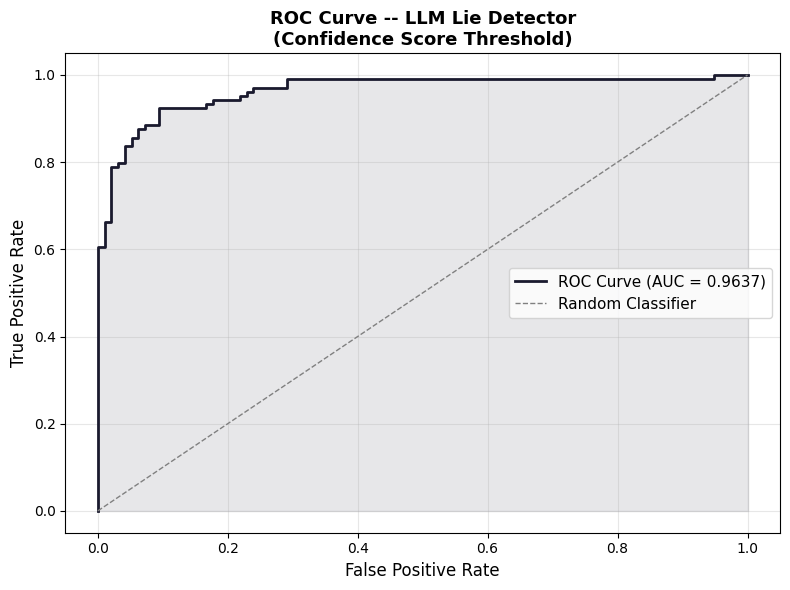

AUC Score: 0.9637
Saved to outputs/roc_curve.png


In [7]:
from sklearn.metrics import roc_curve, auc

true_labels = cal_df['true_label'].tolist()
confidence_scores = cal_df['confidence'].tolist()

fpr, tpr, thresholds = roc_curve(true_labels, confidence_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1a1a2e', linewidth=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',
         linewidth=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#1a1a2e')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve -- LLM Lie Detector\n(Confidence Score Threshold)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC Score: {roc_auc:.4f}")
print("Saved to outputs/roc_curve.png")

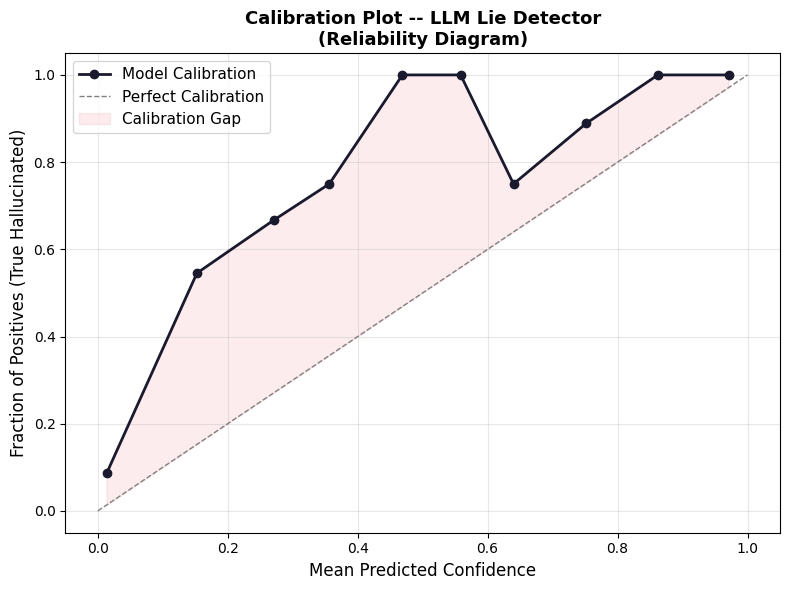

Brier Score: 0.1088 (lower is better, 0.0 = perfect)
Saved to outputs/calibration_plot.png


In [8]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    true_labels,
    confidence_scores,
    n_bins=10,
    strategy='uniform'
)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, color='#1a1a2e', linewidth=2,
         marker='o', markersize=6, label='Model Calibration')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--',
         linewidth=1, label='Perfect Calibration')
plt.fill_between(prob_pred, prob_true, prob_pred,
                 alpha=0.1, color='#e94560', label='Calibration Gap')
plt.xlabel('Mean Predicted Confidence', fontsize=12)
plt.ylabel('Fraction of Positives (True Hallucinated)', fontsize=12)
plt.title('Calibration Plot -- LLM Lie Detector\n(Reliability Diagram)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/calibration_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Brier score -- lower is better (0.0 = perfect, 1.0 = worst)
brier = brier_score_loss(true_labels, confidence_scores)
print(f"Brier Score: {brier:.4f} (lower is better, 0.0 = perfect)")
print("Saved to outputs/calibration_plot.png")

In [9]:
# Define uncertainty thresholds for production use
print("=" * 55)
print("UNCERTAINTY THRESHOLDS FOR PRODUCTION USE")
print("=" * 55)

thresholds = [
    (0.85, 1.00, "HIGH confidence HALLUCINATED -- auto-flag"),
    (0.50, 0.85, "MEDIUM confidence -- flag for review"),
    (0.15, 0.50, "LOW confidence TRUTHFUL -- likely safe"),
    (0.00, 0.15, "HIGH confidence TRUTHFUL -- auto-pass"),
]

for low, high, label in thresholds:
    mask = (cal_df['confidence'] >= low) & (cal_df['confidence'] < high)
    subset = cal_df[mask]
    if len(subset) > 0:
        accuracy = (subset['predicted_label'] == subset['true_label']).mean()
        print(f"\n{label}")
        print(f"  Confidence range: {low:.2f} - {high:.2f}")
        print(f"  Samples in range: {len(subset)}/200 ({len(subset)/200*100:.1f}%)")
        print(f"  Accuracy in range: {accuracy:.4f}")

print("\n" + "=" * 55)

UNCERTAINTY THRESHOLDS FOR PRODUCTION USE

HIGH confidence HALLUCINATED -- auto-flag
  Confidence range: 0.85 - 1.00
  Samples in range: 56/200 (28.0%)
  Accuracy in range: 1.0000

MEDIUM confidence -- flag for review
  Confidence range: 0.50 - 0.85
  Samples in range: 20/200 (10.0%)
  Accuracy in range: 0.9000

LOW confidence TRUTHFUL -- likely safe
  Confidence range: 0.15 - 0.50
  Samples in range: 27/200 (13.5%)
  Accuracy in range: 0.2593

HIGH confidence TRUTHFUL -- auto-pass
  Confidence range: 0.00 - 0.15
  Samples in range: 97/200 (48.5%)
  Accuracy in range: 0.8969



## Uncertainty Threshold Analysis

Four operational zones identified for production deployment:

| Zone | Confidence Range | Samples | Accuracy | Action |
|------|-----------------|---------|----------|--------|
| High HALLUCINATED | 0.85 - 1.00 | 28.0% | 100.00% | Auto-flag |
| Medium | 0.50 - 0.85 | 10.0% | 90.00% | Human review |
| Low TRUTHFUL | 0.15 - 0.50 | 13.5% | 25.93% | Caution |
| High TRUTHFUL | 0.00 - 0.15 | 48.5% | 89.69% | Auto-pass |

Key insight: The model is perfectly reliable at the extremes.
When confidence is above 0.85, accuracy is 100%.
When confidence is below 0.15, accuracy is 90%.
The uncertain middle zone (0.15-0.85) covers only 23.5% of samples
and is where human review adds the most value.

AUC Score: 0.9637
Brier Score: 0.1088